# 🔥 Fire & Smoke Detection using YOLOv8

## Project Overview

This project aims to build an Artificial Intelligence model capable of detecting **Fire** and **Smoke** from images and videos using **YOLOv8**.

### Objectives

- Detect Fire 🔥
- Detect Smoke 💨
- Train using a public dataset
- Evaluate model performance
- Test on custom images and videos

### Tools & Technologies

- Python
- Google Colab
- YOLOv8 (Ultralytics)
- OpenCV
- PyTorch

---

**Author:** Sk. Farhan Alvi

**American International University-Bangladesh (AIUB)**  
Faculty of Science & Technology

---

**Notebook Version:** 1.0

In [ ]:
# ==========================================================
# Fire & Smoke Detection using YOLOv8
# Step 1: Install Required Libraries
# ==========================================================

!pip -q install ultralytics

print("✅ Ultralytics installed successfully!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 36.7 MB/s eta 0:00:00
✅ Ultralytics installed successfully!


# ⚙️ Step 2: Verify Google Colab GPU

Before training the model, we need to check whether Google Colab is connected to a GPU.

A GPU can train deep learning models much faster than a CPU.

We will verify:

- PyTorch version
- CUDA availability
- GPU name

In [ ]:
# ==========================================================
# Step 2: Verify GPU
# ==========================================================

import torch

print("=" * 50)
print("PyTorch Version :", torch.__version__)
print("CUDA Available  :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU Name        :", torch.cuda.get_device_name(0))
else:
    print("No GPU detected. Please enable GPU from:")
    print("Runtime → Change runtime type → Hardware accelerator → GPU")

print("=" * 50)

PyTorch Version : 2.11.0+cu128
CUDA Available  : True
GPU Name        : Tesla T4


# 📂 Step 3: Download the Fire & Smoke Dataset

A deep learning model can only learn from data.

In this step, we will download a public Fire & Smoke Detection dataset that is already formatted for YOLO.

The dataset contains:

- 🔥 Fire images
- 💨 Smoke images
- Bounding box annotations
- Training, validation and testing folders

After downloading, we will verify that all files are present before starting training.

# 🔑 Step 4: Configure Kaggle API

In this step, we will connect Google Colab to Kaggle using the `kaggle.json` API token.

This allows us to download datasets directly from Kaggle without manually downloading ZIP files.

After successful authentication, we can access any public Kaggle dataset with a single command.

In [ ]:
# ==========================================================
# Step 4: Upload Kaggle API Token
# ==========================================================

from google.colab import files

print("📂 Please upload your kaggle.json file")

uploaded = files.upload()

📂 Please upload your kaggle.json file


Saving kaggle.json to kaggle.json


# ⚙️ Step 5: Configure the Kaggle API

In this step, we will configure the Kaggle API.

The uploaded `kaggle.json` file will be moved to the correct location and appropriate permissions will be set.

After this step, Google Colab will be able to communicate securely with Kaggle.

In [ ]:
# ==========================================================
# Step 5: Configure Kaggle API
# ==========================================================

import os
import shutil

# Create the Kaggle directory
os.makedirs("/root/.kaggle", exist_ok=True)

# Move the uploaded API key
shutil.move("kaggle.json", "/root/.kaggle/kaggle.json")

# Set secure permissions
os.chmod("/root/.kaggle/kaggle.json", 0o600)

print("✅ Kaggle API configured successfully!")

✅ Kaggle API configured successfully!


# ✅ Step 6: Verify the Kaggle API

Before downloading the dataset, we should verify that the Kaggle API is working correctly.

If everything is configured properly, the command will display your Kaggle username.

In [ ]:
# ==========================================================
# Step 6: Verify Kaggle API
# ==========================================================

!kaggle config view

Configuration values from /root/.kaggle
- username: farhanalvi315
- auth_method: LEGACY_API_KEY
- path: None
- proxy: None
- competition: None


# 📥 Step 7: Download the Fire & Smoke Dataset

In this step, we will download the Fire & Smoke Detection dataset from Kaggle.

The dataset contains:

- 🔥 Fire
- 💨 Smoke

The dataset is already annotated in YOLO format, so it can be used directly for training YOLOv8.

In [ ]:
# ==========================================================
# Step 7: Download Dataset from Kaggle
# ==========================================================

!kaggle datasets download -d sayedgamal99/smoke-fire-detection-yolo

print("✅ Dataset downloaded successfully!")

Dataset URL: https://www.kaggle.com/datasets/sayedgamal99/smoke-fire-detection-yolo
License(s): CC0-1.0
100% 2.84G/2.84G [00:30<00:00, 100MB/s]

✅ Dataset downloaded successfully!


In [ ]:
# ==========================================================
# Step 8: Extract Dataset
# ==========================================================

import zipfile

zip_path = "/content/smoke-fire-detection-yolo.zip"
extract_path = "/content/fire_smoke_dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Dataset extracted successfully!")

✅ Dataset extracted successfully!


In [ ]:
# ==========================================================
# Step 9: View Dataset Structure
# ==========================================================

import os

for root, dirs, files in os.walk("/content/fire_smoke_dataset"):
    print(root)
    print("-" * 60)

    for d in dirs:
        print("📁", d)

    for f in files[:5]:
        print("📄", f)

    print()

/content/fire_smoke_dataset
------------------------------------------------------------
📁 data
📄 data.yaml

/content/fire_smoke_dataset/data
------------------------------------------------------------
📁 test
📁 train
📁 val

/content/fire_smoke_dataset/data/test
------------------------------------------------------------
📁 labels
📁 images

/content/fire_smoke_dataset/data/test/labels
------------------------------------------------------------
📄 WEB10944.txt
📄 WEB10470.txt
📄 WEB11659.txt
📄 WEB11703.txt
📄 AoF06778.txt

/content/fire_smoke_dataset/data/test/images
------------------------------------------------------------
📄 PublicDataset01070.jpg
📄 PublicDataset01269.jpg
📄 WEB11744.jpg
📄 AoF07680.jpg
📄 WEB09584.jpg

/content/fire_smoke_dataset/data/train
------------------------------------------------------------
📁 labels
📁 images

/content/fire_smoke_dataset/data/train/labels
------------------------------------------------------------
📄 WEB07615.txt
📄 PublicDataset00616.txt
📄 AoF06

# 🔍 Step 8: Explore the Dataset

Before training the model, we will inspect the dataset.

This helps us understand:

- Number of classes
- Class names
- Training images
- Validation images
- Test images
- Dataset configuration

In [ ]:
# ==========================================================
# Step 10: Read data.yaml
# ==========================================================

import yaml

yaml_path = "/content/fire_smoke_dataset/data.yaml"

with open(yaml_path, "r") as file:
    data = yaml.safe_load(file)

print("=" * 50)
print("Dataset Information")
print("=" * 50)

for key, value in data.items():
    print(f"{key}: {value}")

Dataset Information
path: /kaggle/working/D Fire Dataset
train: data/train/images
val: data/val/images
test: data/test/images
names: ['smoke', 'fire']
nc: 2
train_count: 14122
val_count: 3099
test_count: 4306


In [ ]:
# ==========================================================
# Step 11: Count Images
# ==========================================================

import os

train_images = "/content/fire_smoke_dataset/data/train/images"
val_images = "/content/fire_smoke_dataset/data/val/images"
test_images = "/content/fire_smoke_dataset/data/test/images"

print("=" * 50)
print("Number of Images")
print("=" * 50)

print("Training Images  :", len(os.listdir(train_images)))
print("Validation Images:", len(os.listdir(val_images)))
print("Testing Images   :", len(os.listdir(test_images)))

Number of Images
Training Images  : 14122
Validation Images: 3099
Testing Images   : 4306


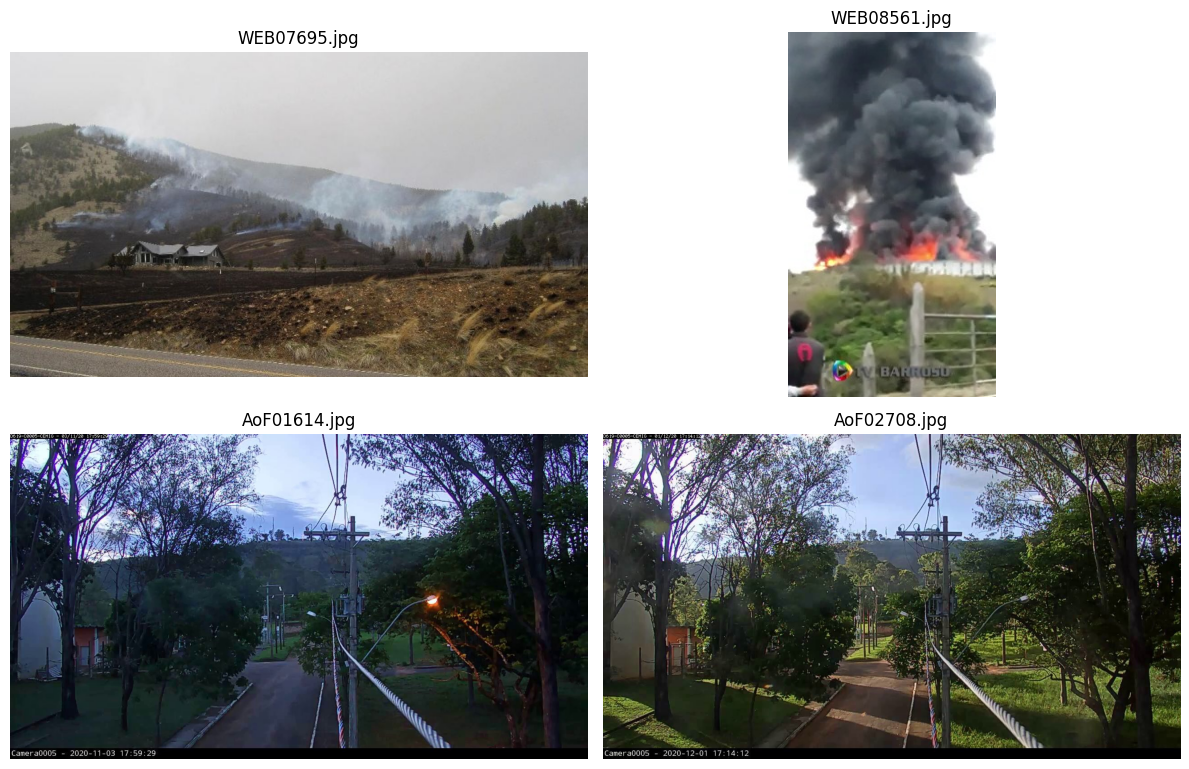

In [ ]:
# ==========================================================
# Step 12: Display Sample Images
# ==========================================================

import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

image_folder = "/content/fire_smoke_dataset/data/train/images"

sample_images = random.sample(os.listdir(image_folder), 4)

plt.figure(figsize=(12, 8))

for i, image_name in enumerate(sample_images):
    image_path = os.path.join(image_folder, image_name)

    img = mpimg.imread(image_path)

    plt.subplot(2, 2, i + 1)
    plt.imshow(img)
    plt.title(image_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

# 🚀 Step 11: Train the YOLOv8 Fire & Smoke Detection Model

The model will learn to detect two classes:

- 🔥 Fire
- 💨 Smoke

Training Configuration:

- Model: YOLOv8 Small (`yolov8s.pt`)
- Epochs: 50
- Image Size: 640 × 640
- Batch Size: 16
- Device: Tesla T4 GPU

After training, the best model weights will be saved automatically.

In [ ]:
# ==========================================================
# Step 15: Display Training Configuration
# ==========================================================

config = {
    "Model": "YOLOv8 Small (yolov8s.pt)",
    "Dataset": "D-Fire Dataset",
    "Classes": ["Smoke", "Fire"],
    "Training Images": 14122,
    "Validation Images": 3099,
    "Testing Images": 4306,
    "Epochs": 40,
    "Batch Size": 16,
    "Image Size": 640,
    "GPU": "Tesla T4"
}

print("=" * 55)
print("🔥 FIRE & SMOKE DETECTION TRAINING CONFIGURATION")
print("=" * 55)

for key, value in config.items():
    print(f"{key:<18}: {value}")

🔥 FIRE & SMOKE DETECTION TRAINING CONFIGURATION
Model             : YOLOv8 Small (yolov8s.pt)
Dataset           : D-Fire Dataset
Classes           : ['Smoke', 'Fire']
Training Images   : 14122
Validation Images : 3099
Testing Images    : 4306
Epochs            : 40
Batch Size        : 16
Image Size        : 640
GPU               : Tesla T4


# 🛠️ Step 10: Fix the Dataset Configuration

The original dataset was created on Kaggle, so the `data.yaml` file contains the original Kaggle path.

We will update it to the correct Google Colab path before training.

In [ ]:
# ==========================================================
# Step 14: Fix data.yaml for Google Colab
# ==========================================================

import yaml

yaml_path = "/content/fire_smoke_dataset/data.yaml"

with open(yaml_path, "r") as file:
    data = yaml.safe_load(file)

# Update the dataset path for Colab
data["path"] = "/content/fire_smoke_dataset"

with open(yaml_path, "w") as file:
    yaml.dump(data, file, default_flow_style=False)

print("✅ data.yaml updated successfully!")
print("\nUpdated Configuration:\n")

with open(yaml_path, "r") as file:
    print(file.read())

# 🚀 Step 9: Train the YOLOv8 Model

In this step, we will train the YOLOv8 model using the Fire & Smoke dataset.

Training Configuration

- Model: YOLOv8s
- Epochs: 50
- Image Size: 640 × 640
- Batch Size: 16
- Classes:
  - Smoke
  - Fire

The trained model will automatically be saved in the `runs/detect/` directory.

In [ ]:
# ==========================================================
# Step 13: Train YOLOv8
# ==========================================================

from ultralytics import YOLO

# Load the YOLOv8 Small model
model = YOLO("yolov8s.pt")

# Train the model
results = model.train(
    data="/content/fire_smoke_dataset/data.yaml",
    epochs=40,
    imgsz=640,
    batch=16,
    device=0,
    project="FireSmokeDetection",
    name="YOLOv8s",
    pretrained=True,
    verbose=True
)

print("✅ Training Completed!")

Ultralytics 8.4.113 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/fire_smoke_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=YOLOv8s-3, nbs=64, nms=

# 🧪 Step 17: Evaluate the Trained Model on the Test Dataset

Training is complete.

Now we evaluate the best model using the unseen test dataset.

This tells us how well the model generalizes to new images.

We will obtain:

- Precision
- Recall
- mAP@50
- mAP@50-95
- Final evaluation metrics

In [ ]:
from ultralytics import YOLO

# Load the best trained model
model = YOLO("/content/runs/detect/FireSmokeDetection/YOLOv8s-3/weights/best.pt")

# Evaluate on the unseen test dataset
metrics = model.val(
    data="/content/fire_smoke_dataset/data.yaml",
    split="test",
    imgsz=640,
    batch=16,
    device=0
)

Ultralytics 8.4.113 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.0±0.0 ms, read: 14.2±11.9 MB/s, size: 51.5 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /content/fire_smoke_dataset/data/test/labels... 4306 images, 2005 backgrounds, 4 corrupt: 100% ━━━━━━━━━━━━ 4306/4306 689.2it/s 6.2s
val: /content/fire_smoke_dataset/data/test/images/WEB10769.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     1.0297]
val: /content/fire_smoke_dataset/data/test/images/WEB10775.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     1.0156]
val: /content/fire_smoke_dataset/data/test/images/WEB11243.jpg: corrupt JPEG restored and saved
val: /content/fire_smoke_dataset/data/test/images/

# 📊 Step 18: Display Final Performance

After evaluating the model, we display the main performance metrics.

These metrics summarize the model's performance on completely unseen test images.

In [ ]:
print("="*50)
print("Final Test Performance")
print("="*50)

print(f"Precision : {metrics.box.mp:.4f}")
print(f"Recall    : {metrics.box.mr:.4f}")
print(f"mAP@50    : {metrics.box.map50:.4f}")
print(f"mAP@50-95 : {metrics.box.map:.4f}")

Final Test Performance
Precision : 0.7768
Recall    : 0.6874
mAP@50    : 0.7650
mAP@50-95 : 0.4398


# 📈 Step 19: Visualize Model Performance

YOLO automatically generated several evaluation plots during training.

In this step, we display them inside the notebook for easier analysis.

These include:

- Training Results
- Confusion Matrix
- Normalized Confusion Matrix
- Precision–Recall Curve
- Precision–Confidence Curve
- Recall–Confidence Curve


results.png


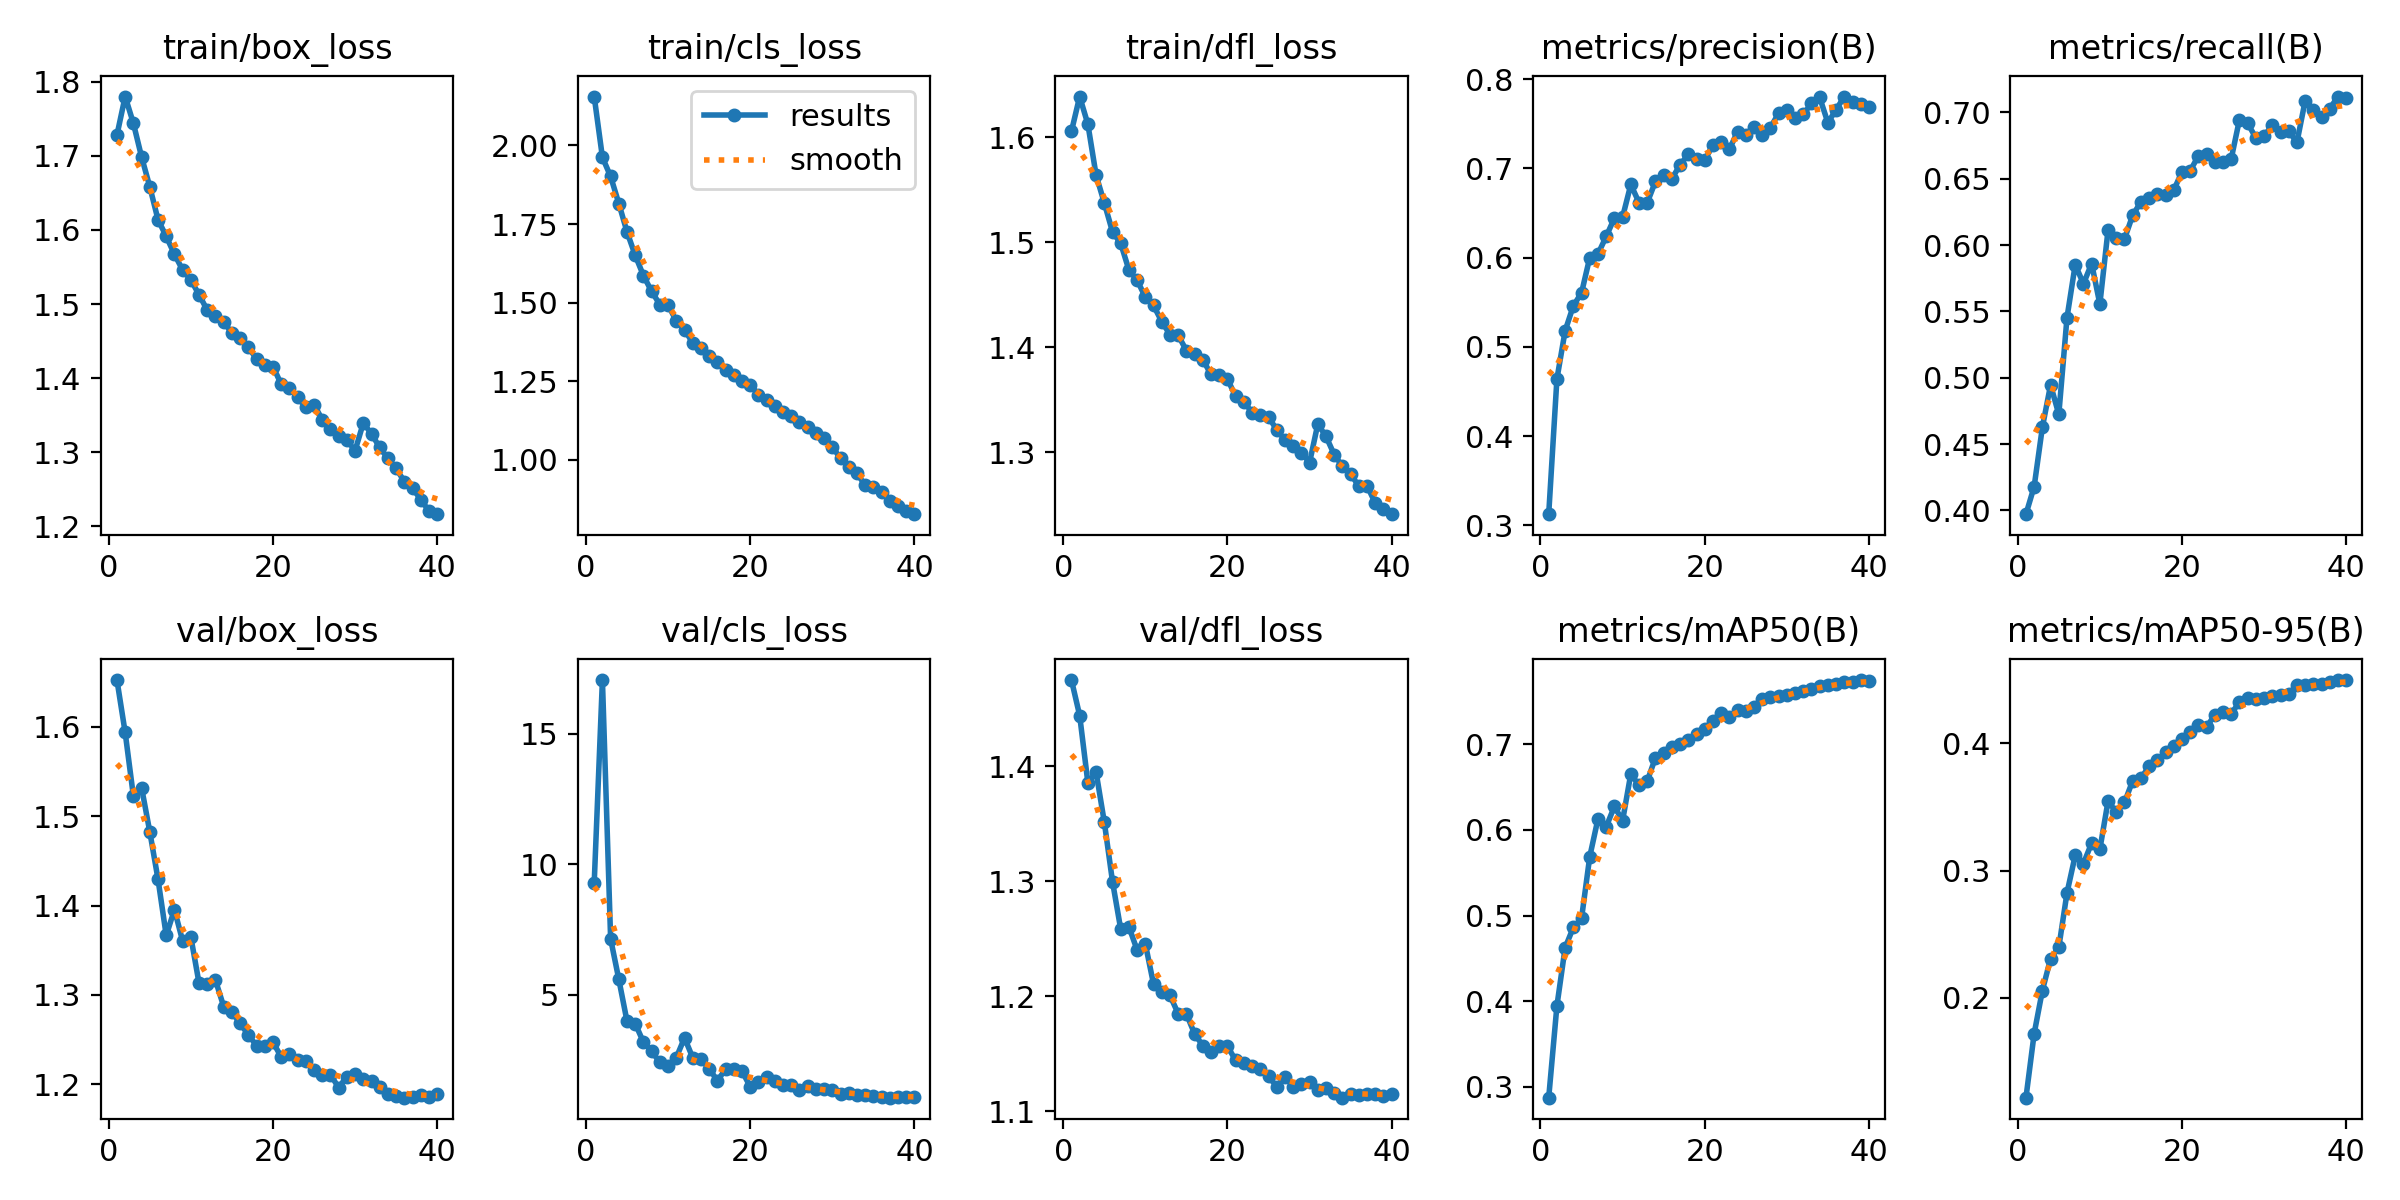


confusion_matrix.png


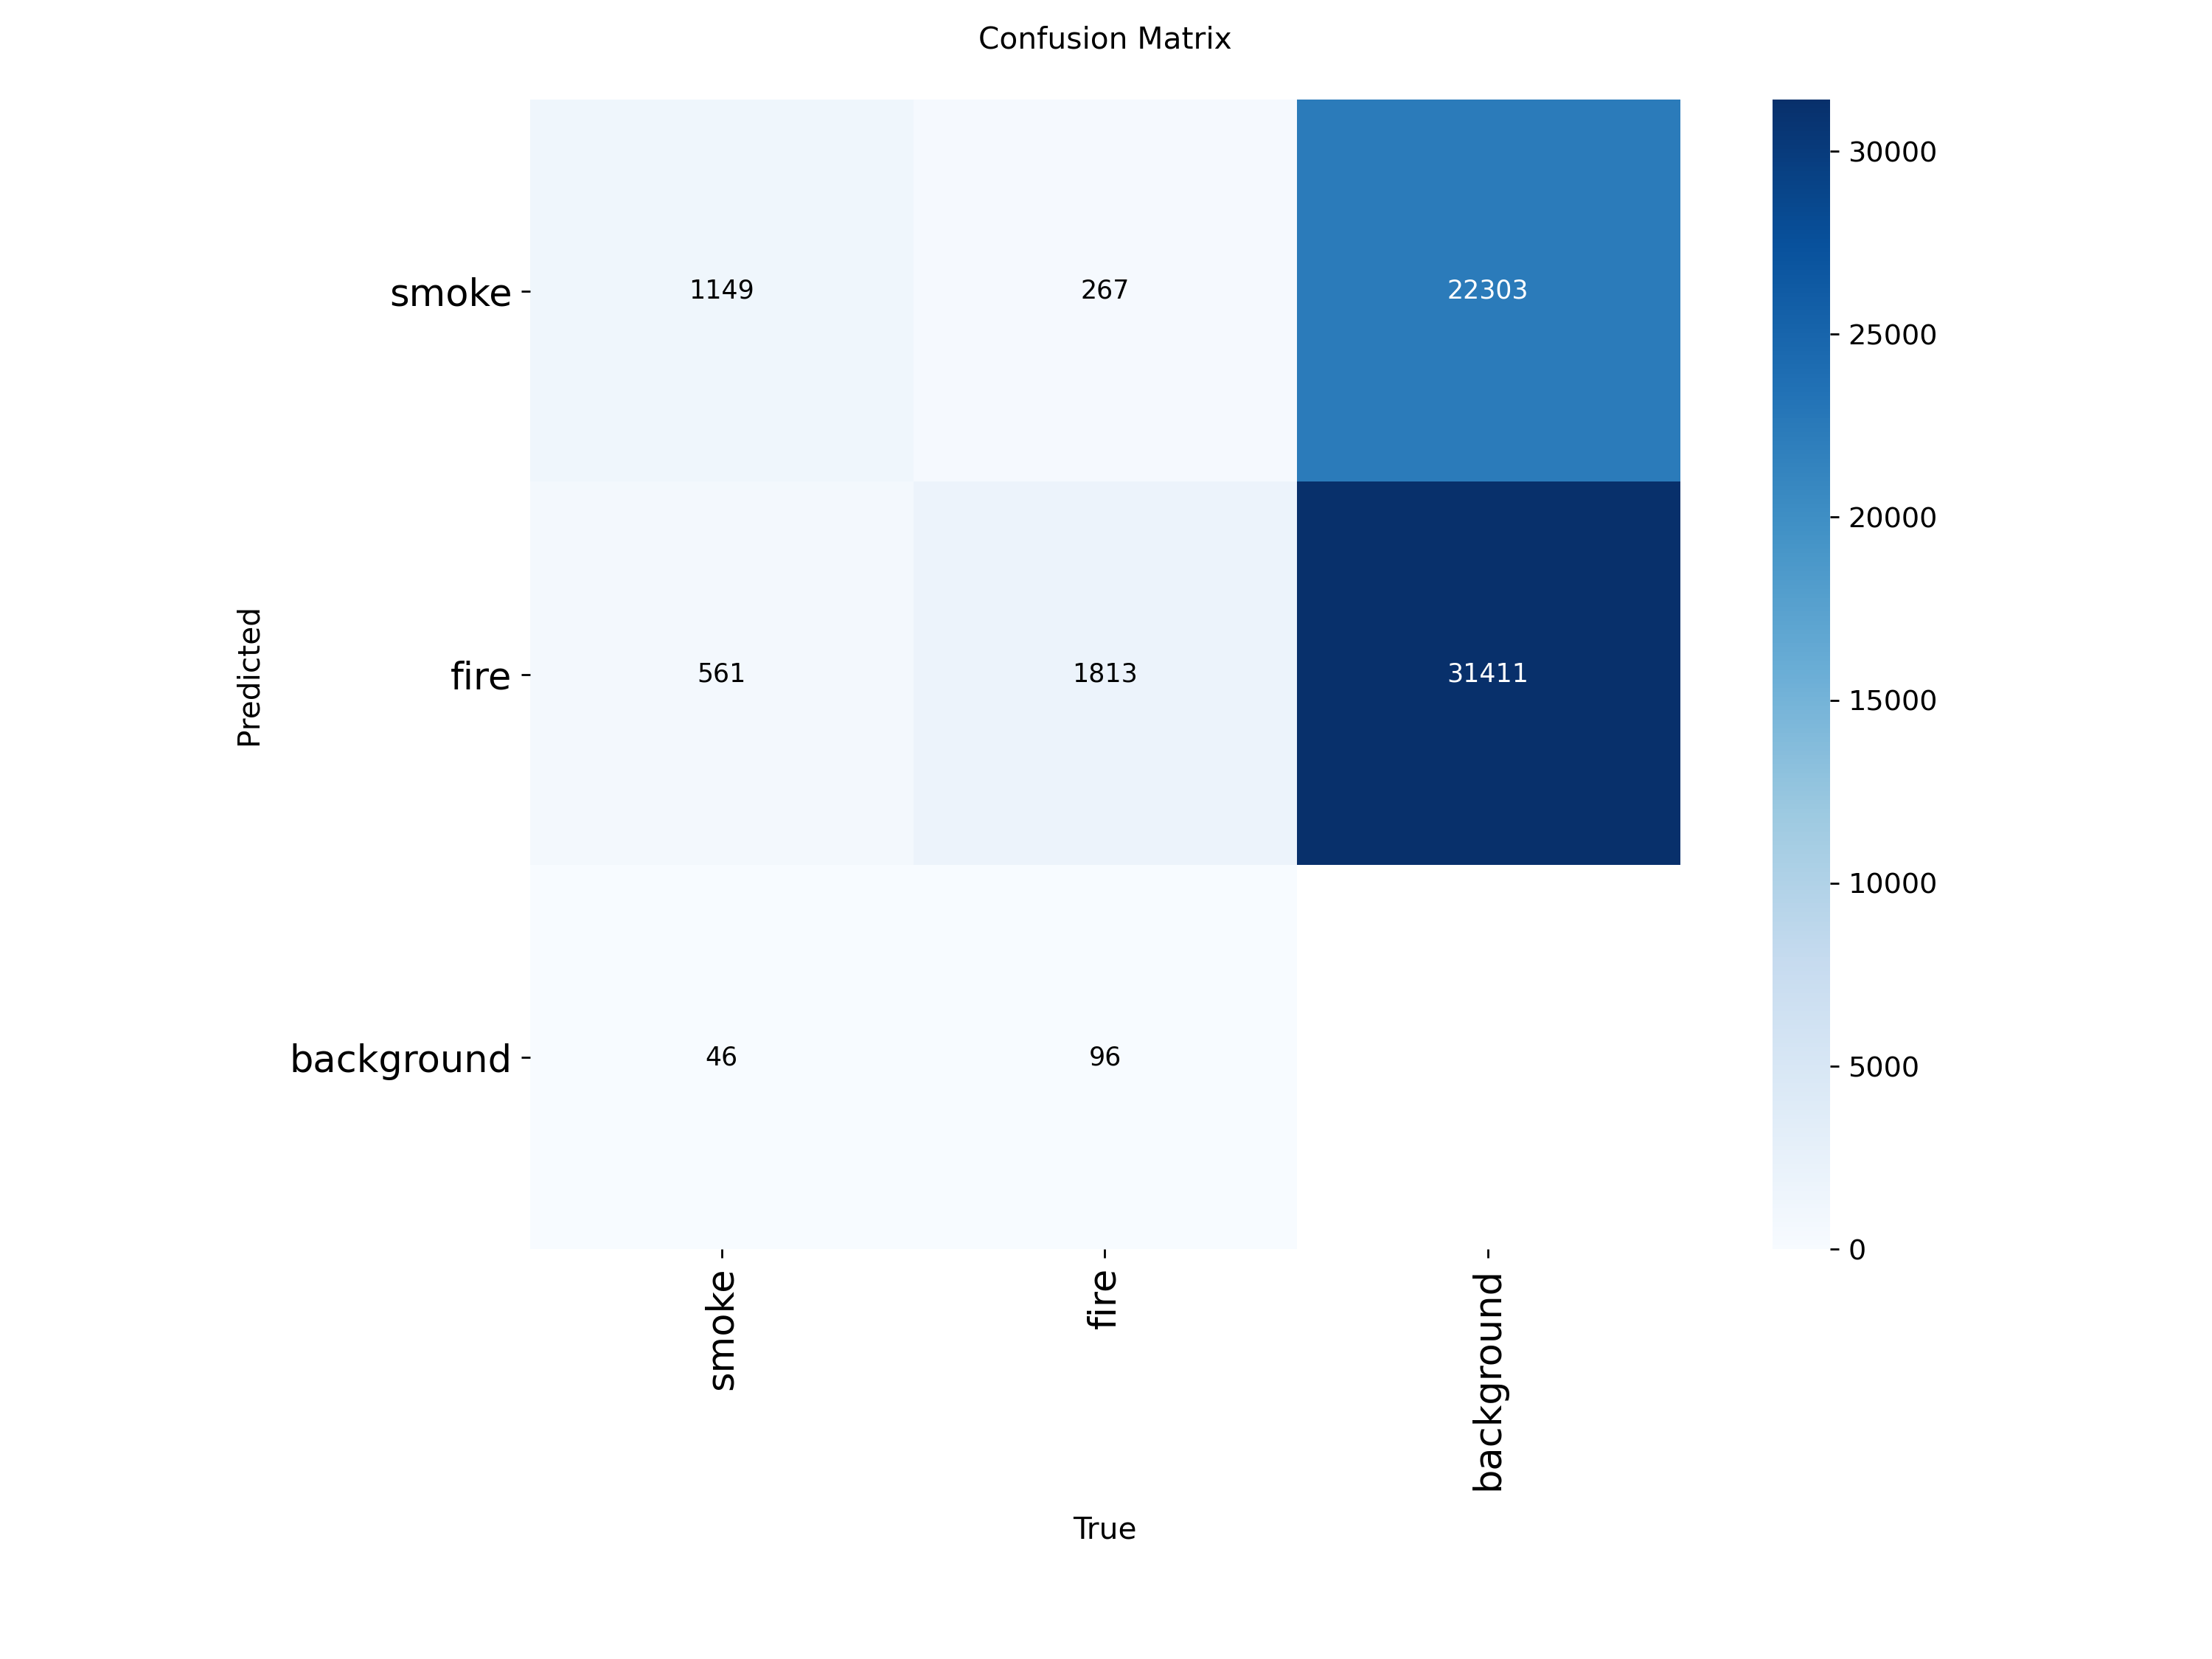


confusion_matrix_normalized.png


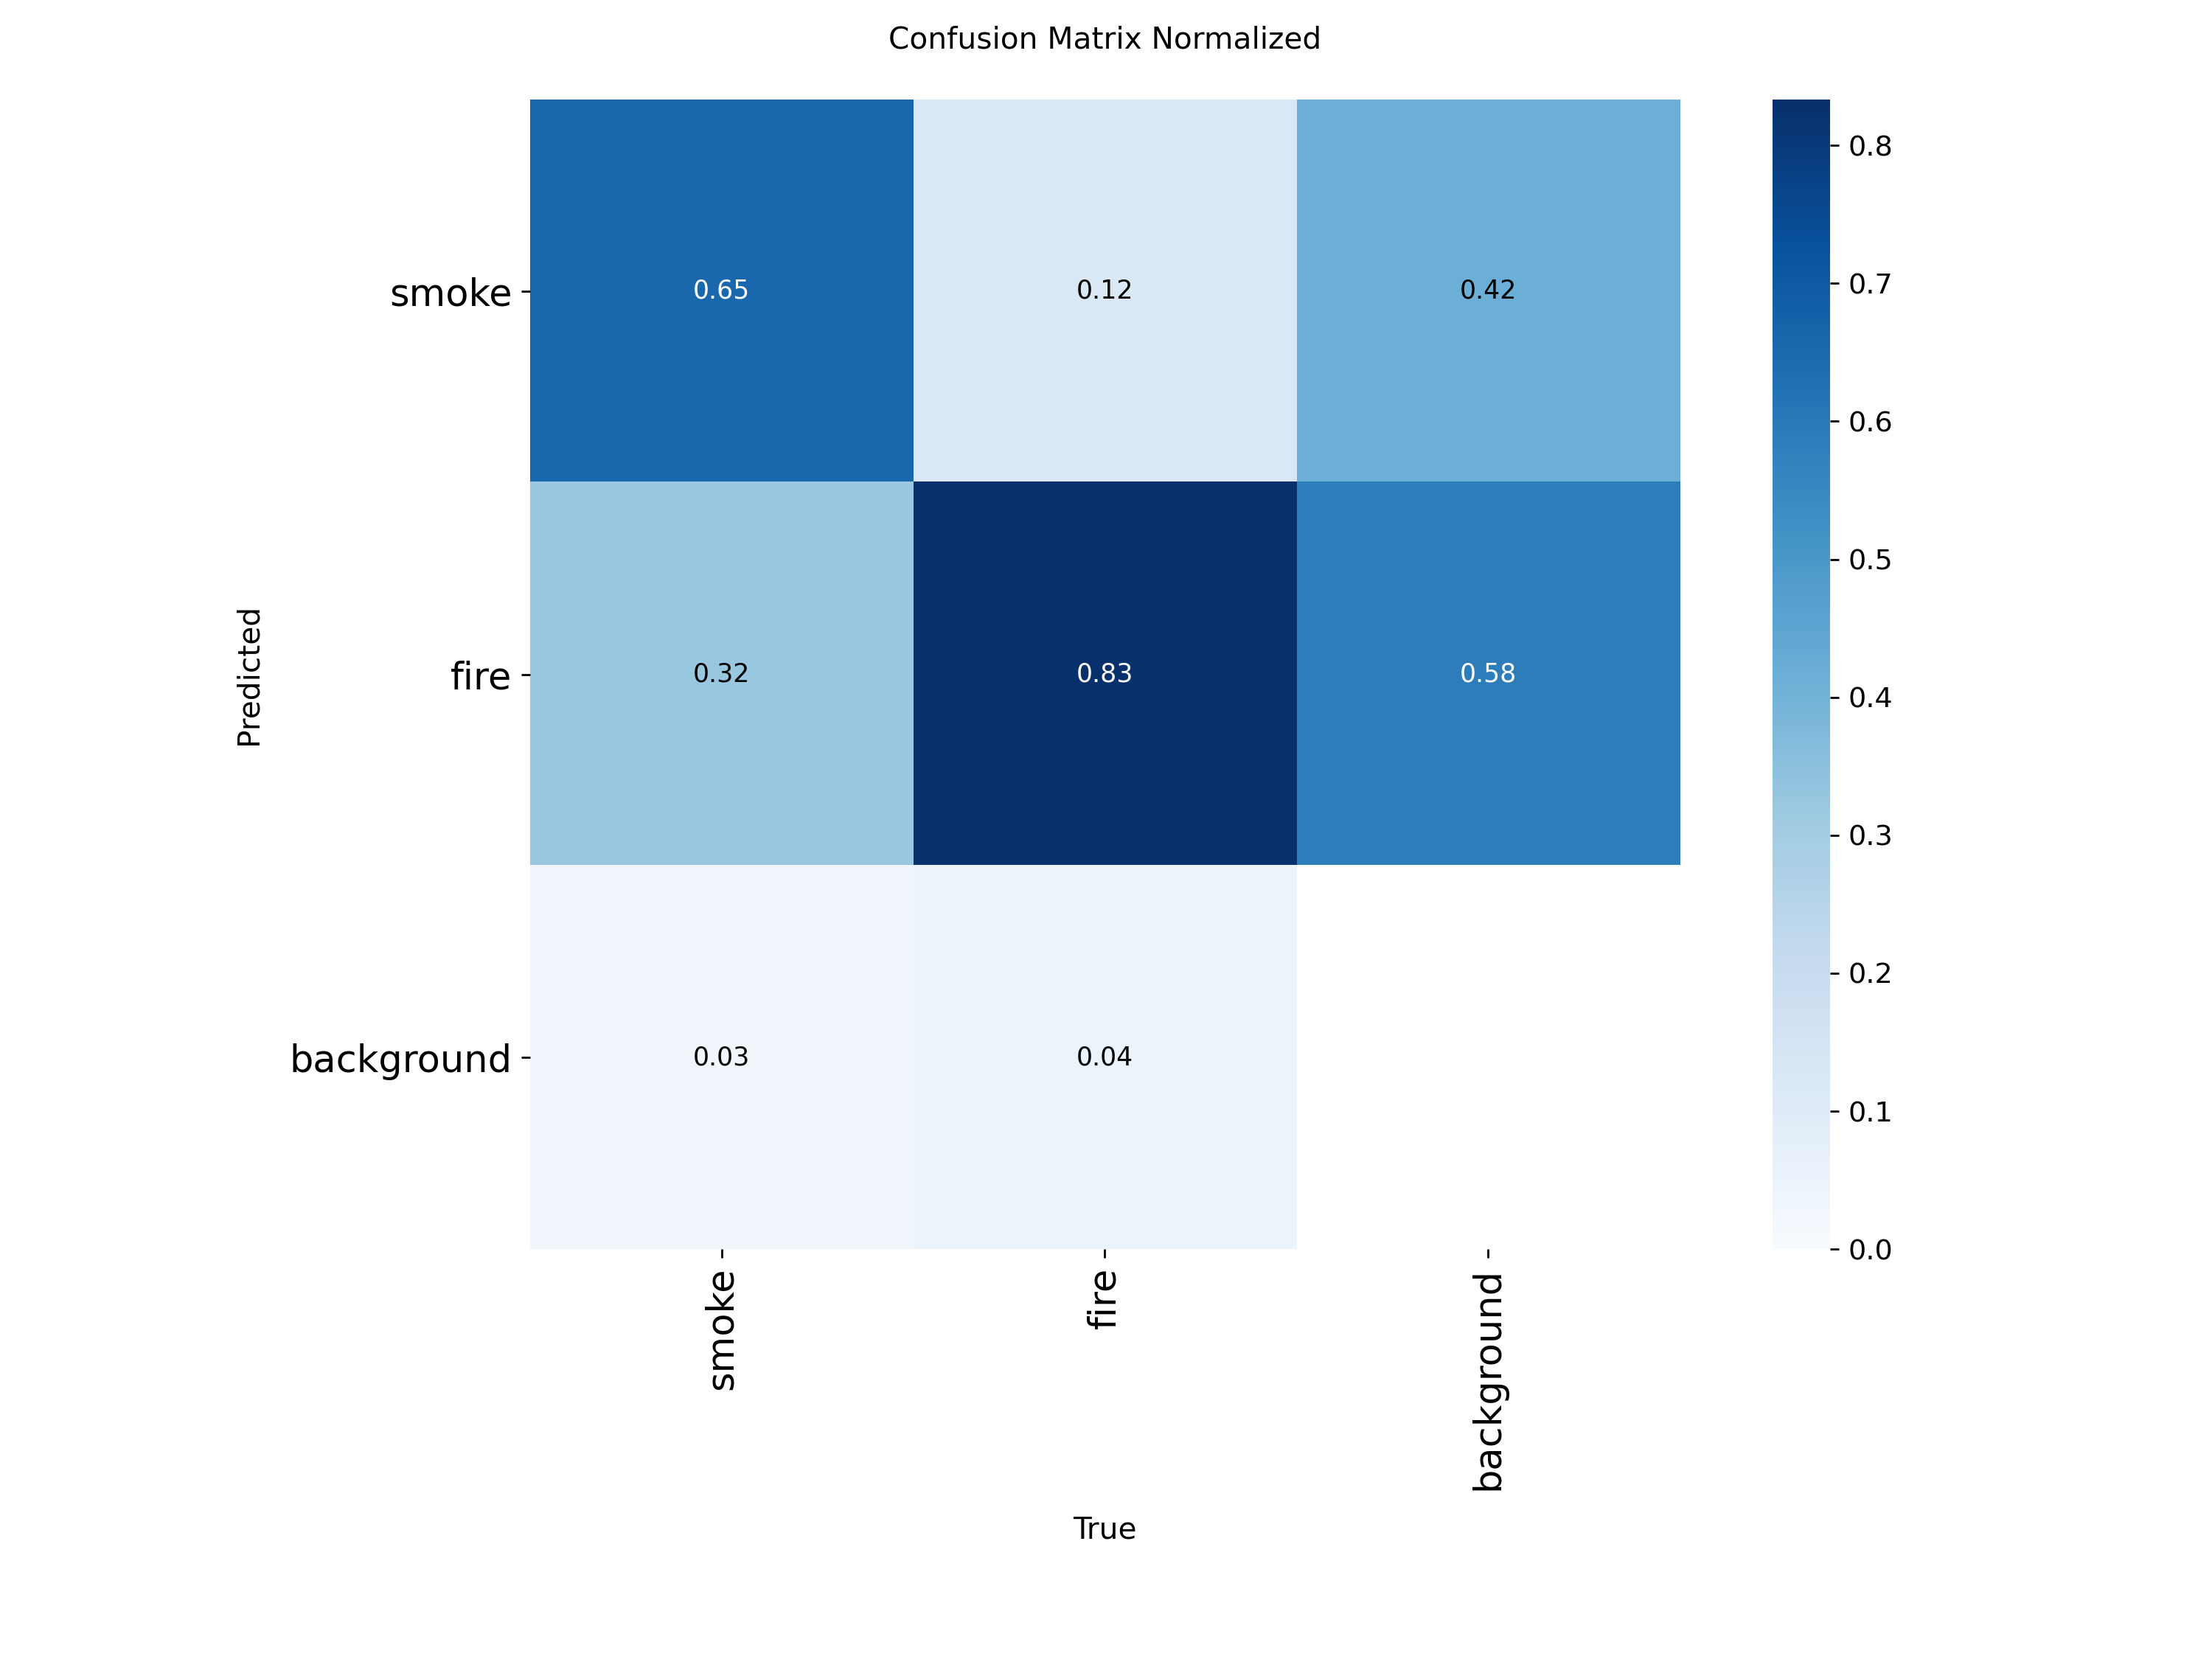


BoxPR_curve.png


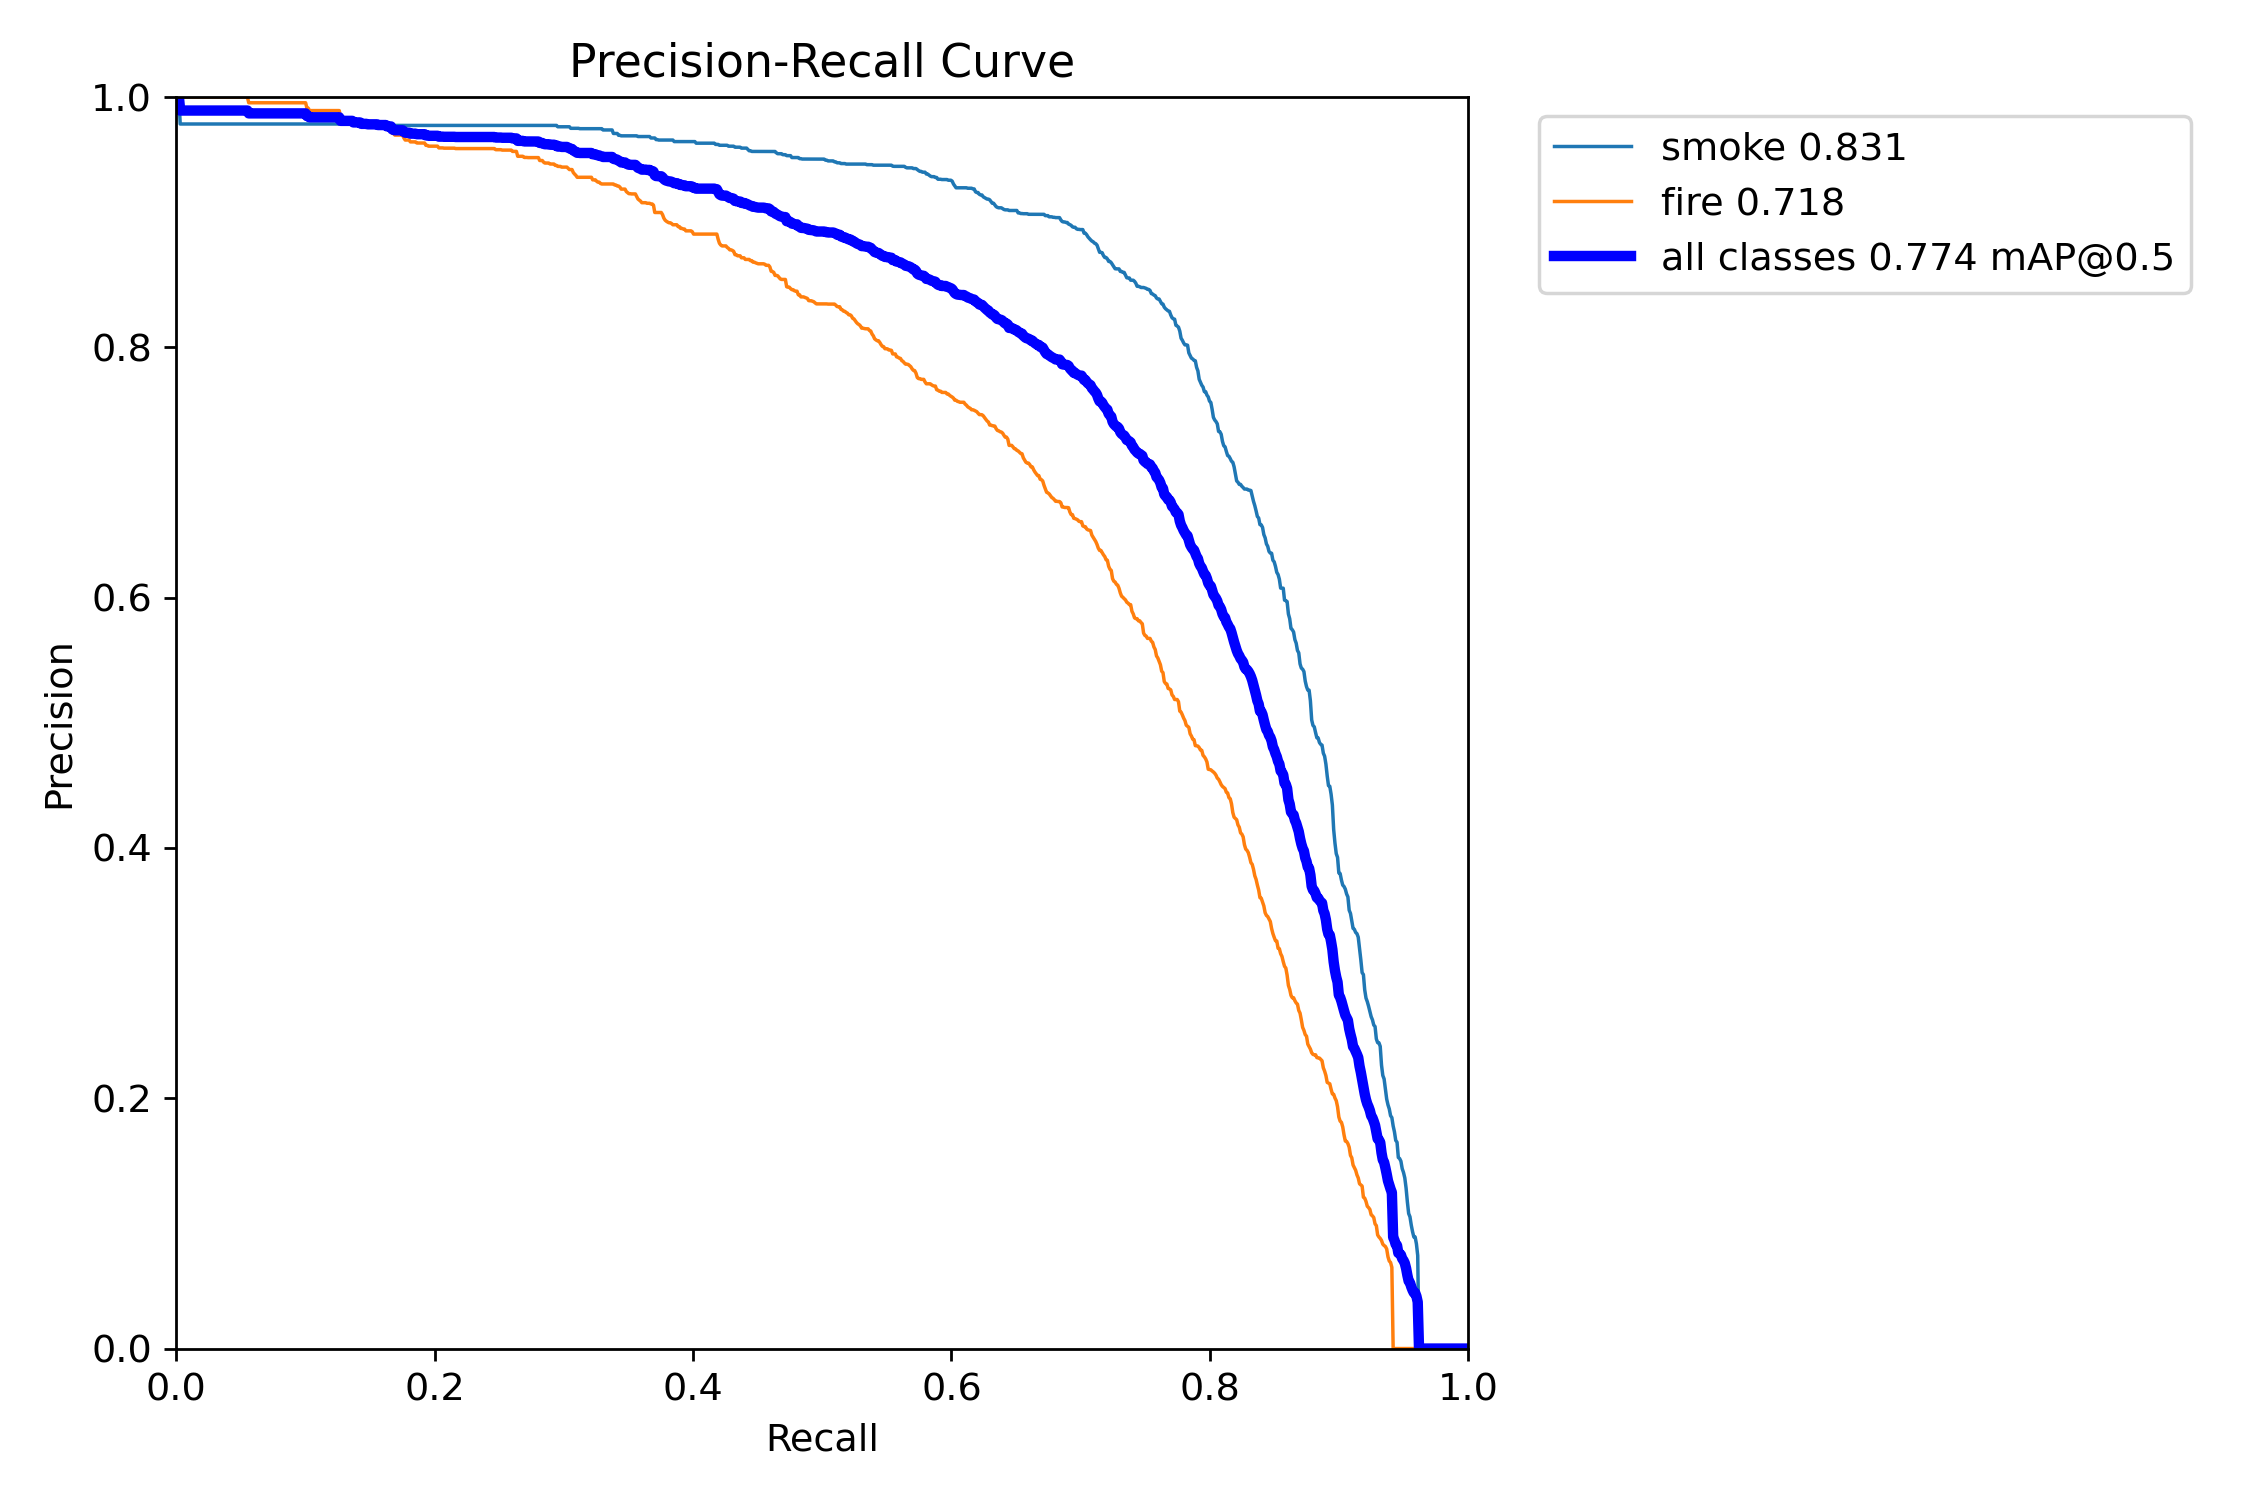


BoxP_curve.png


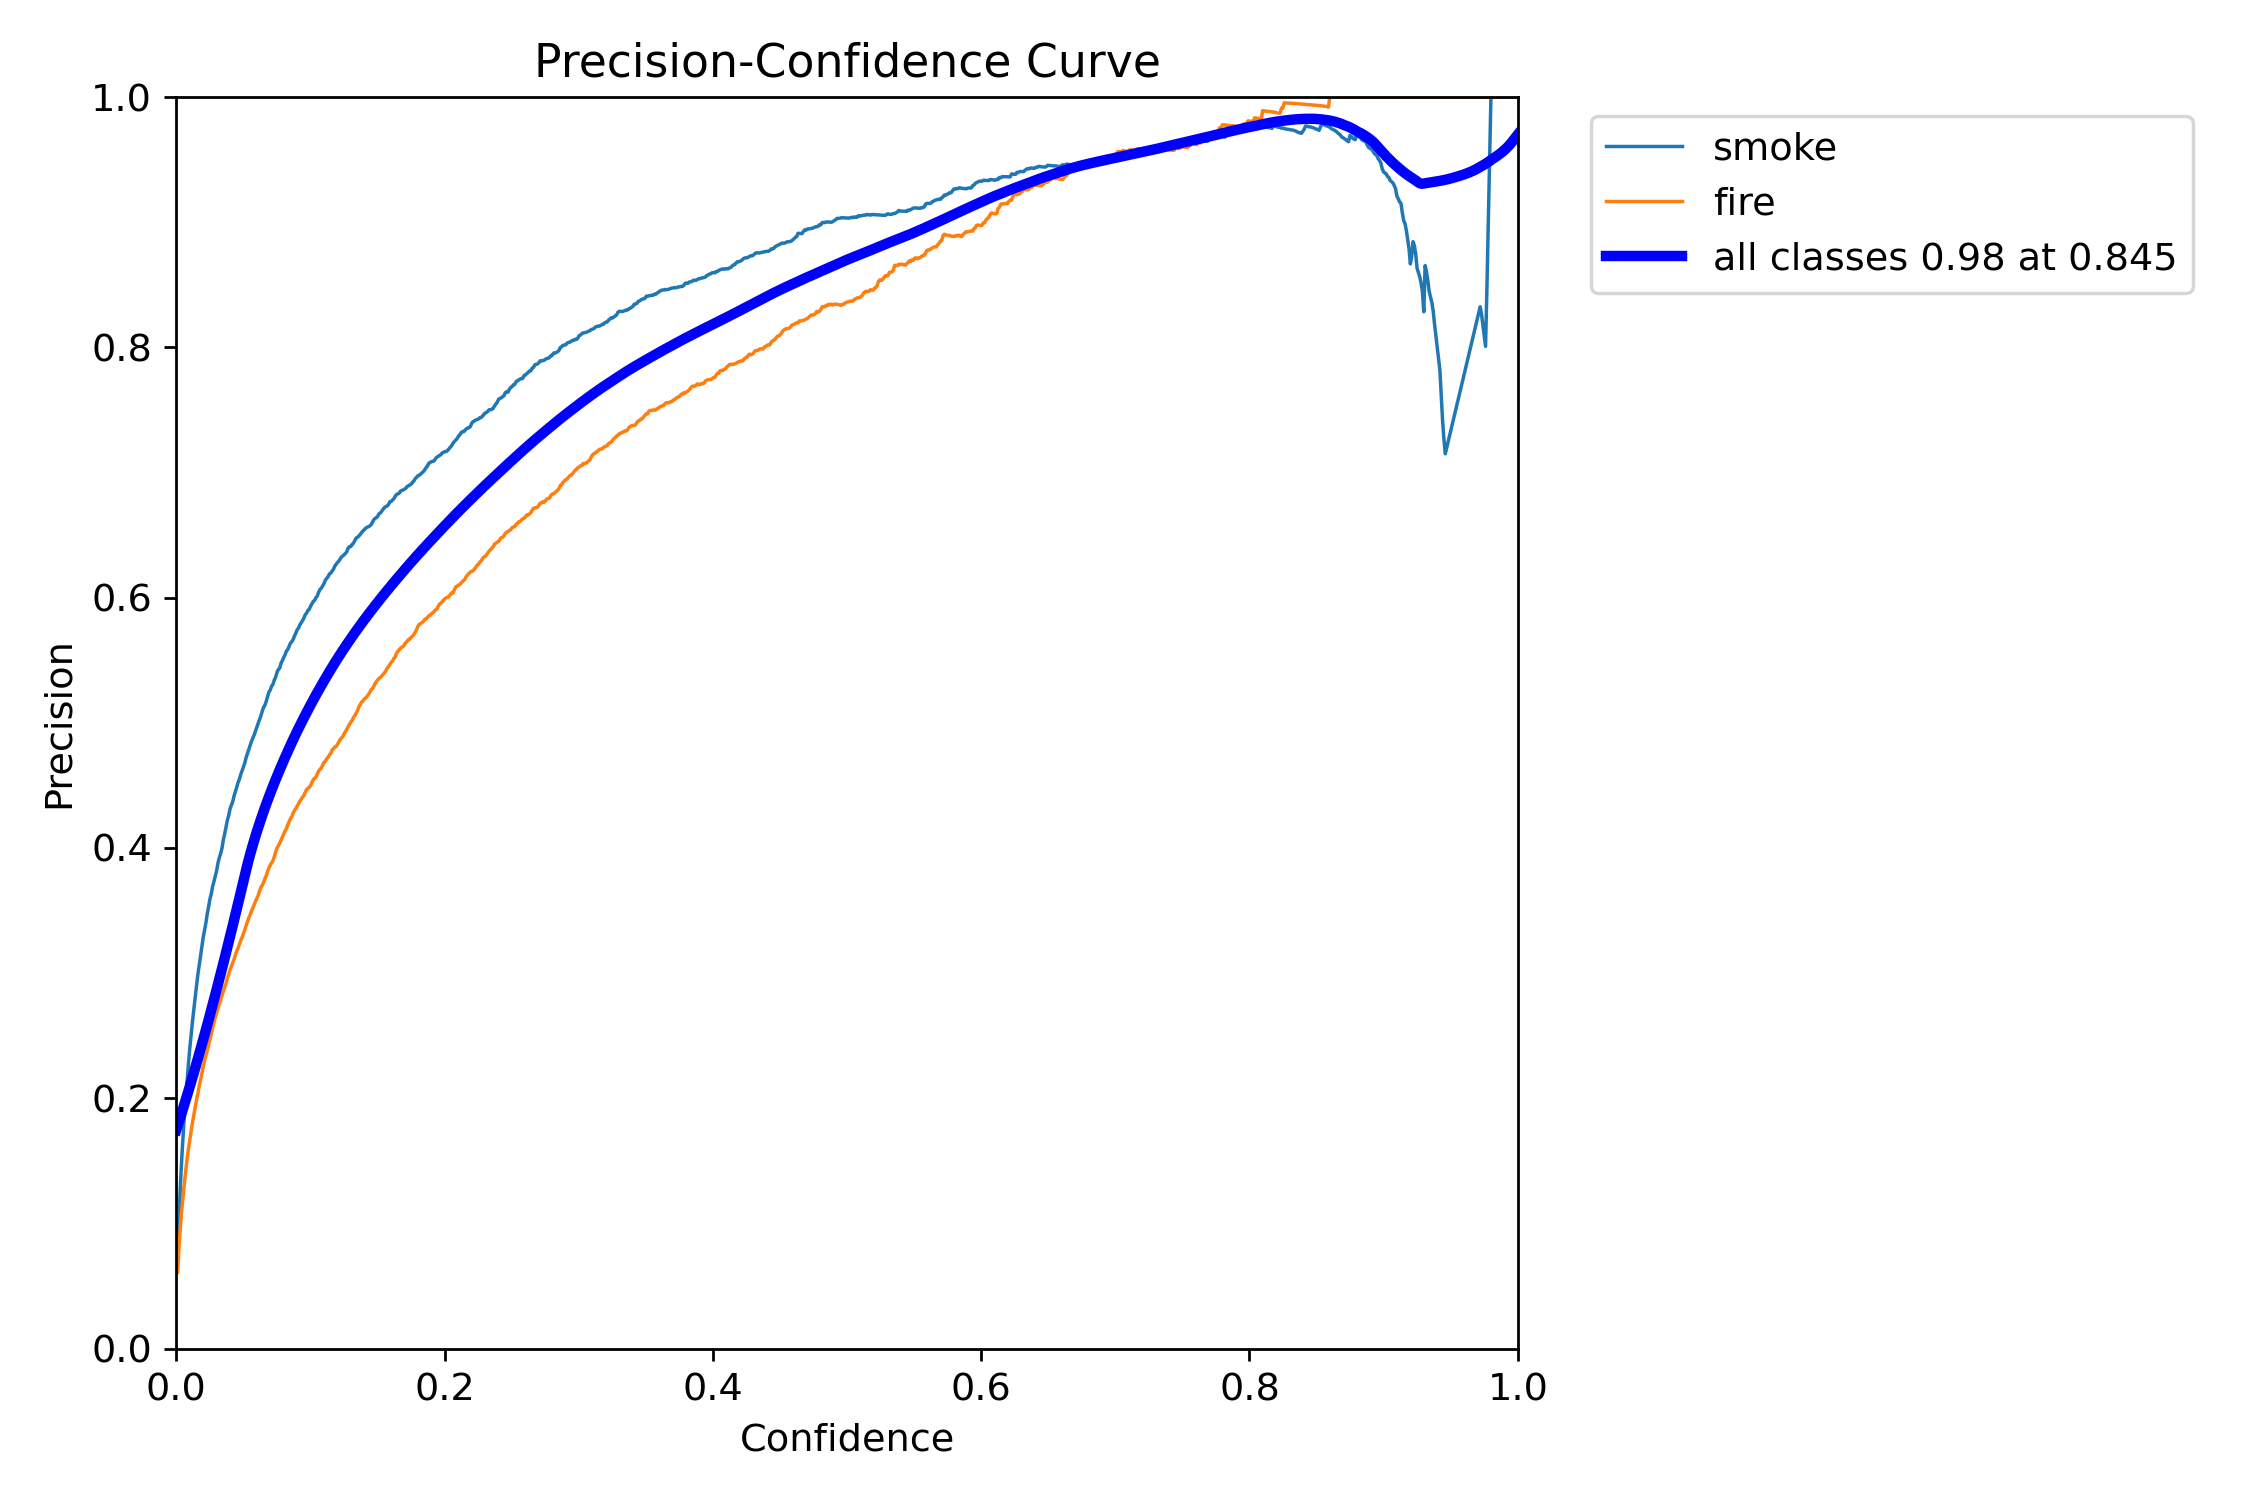


BoxR_curve.png


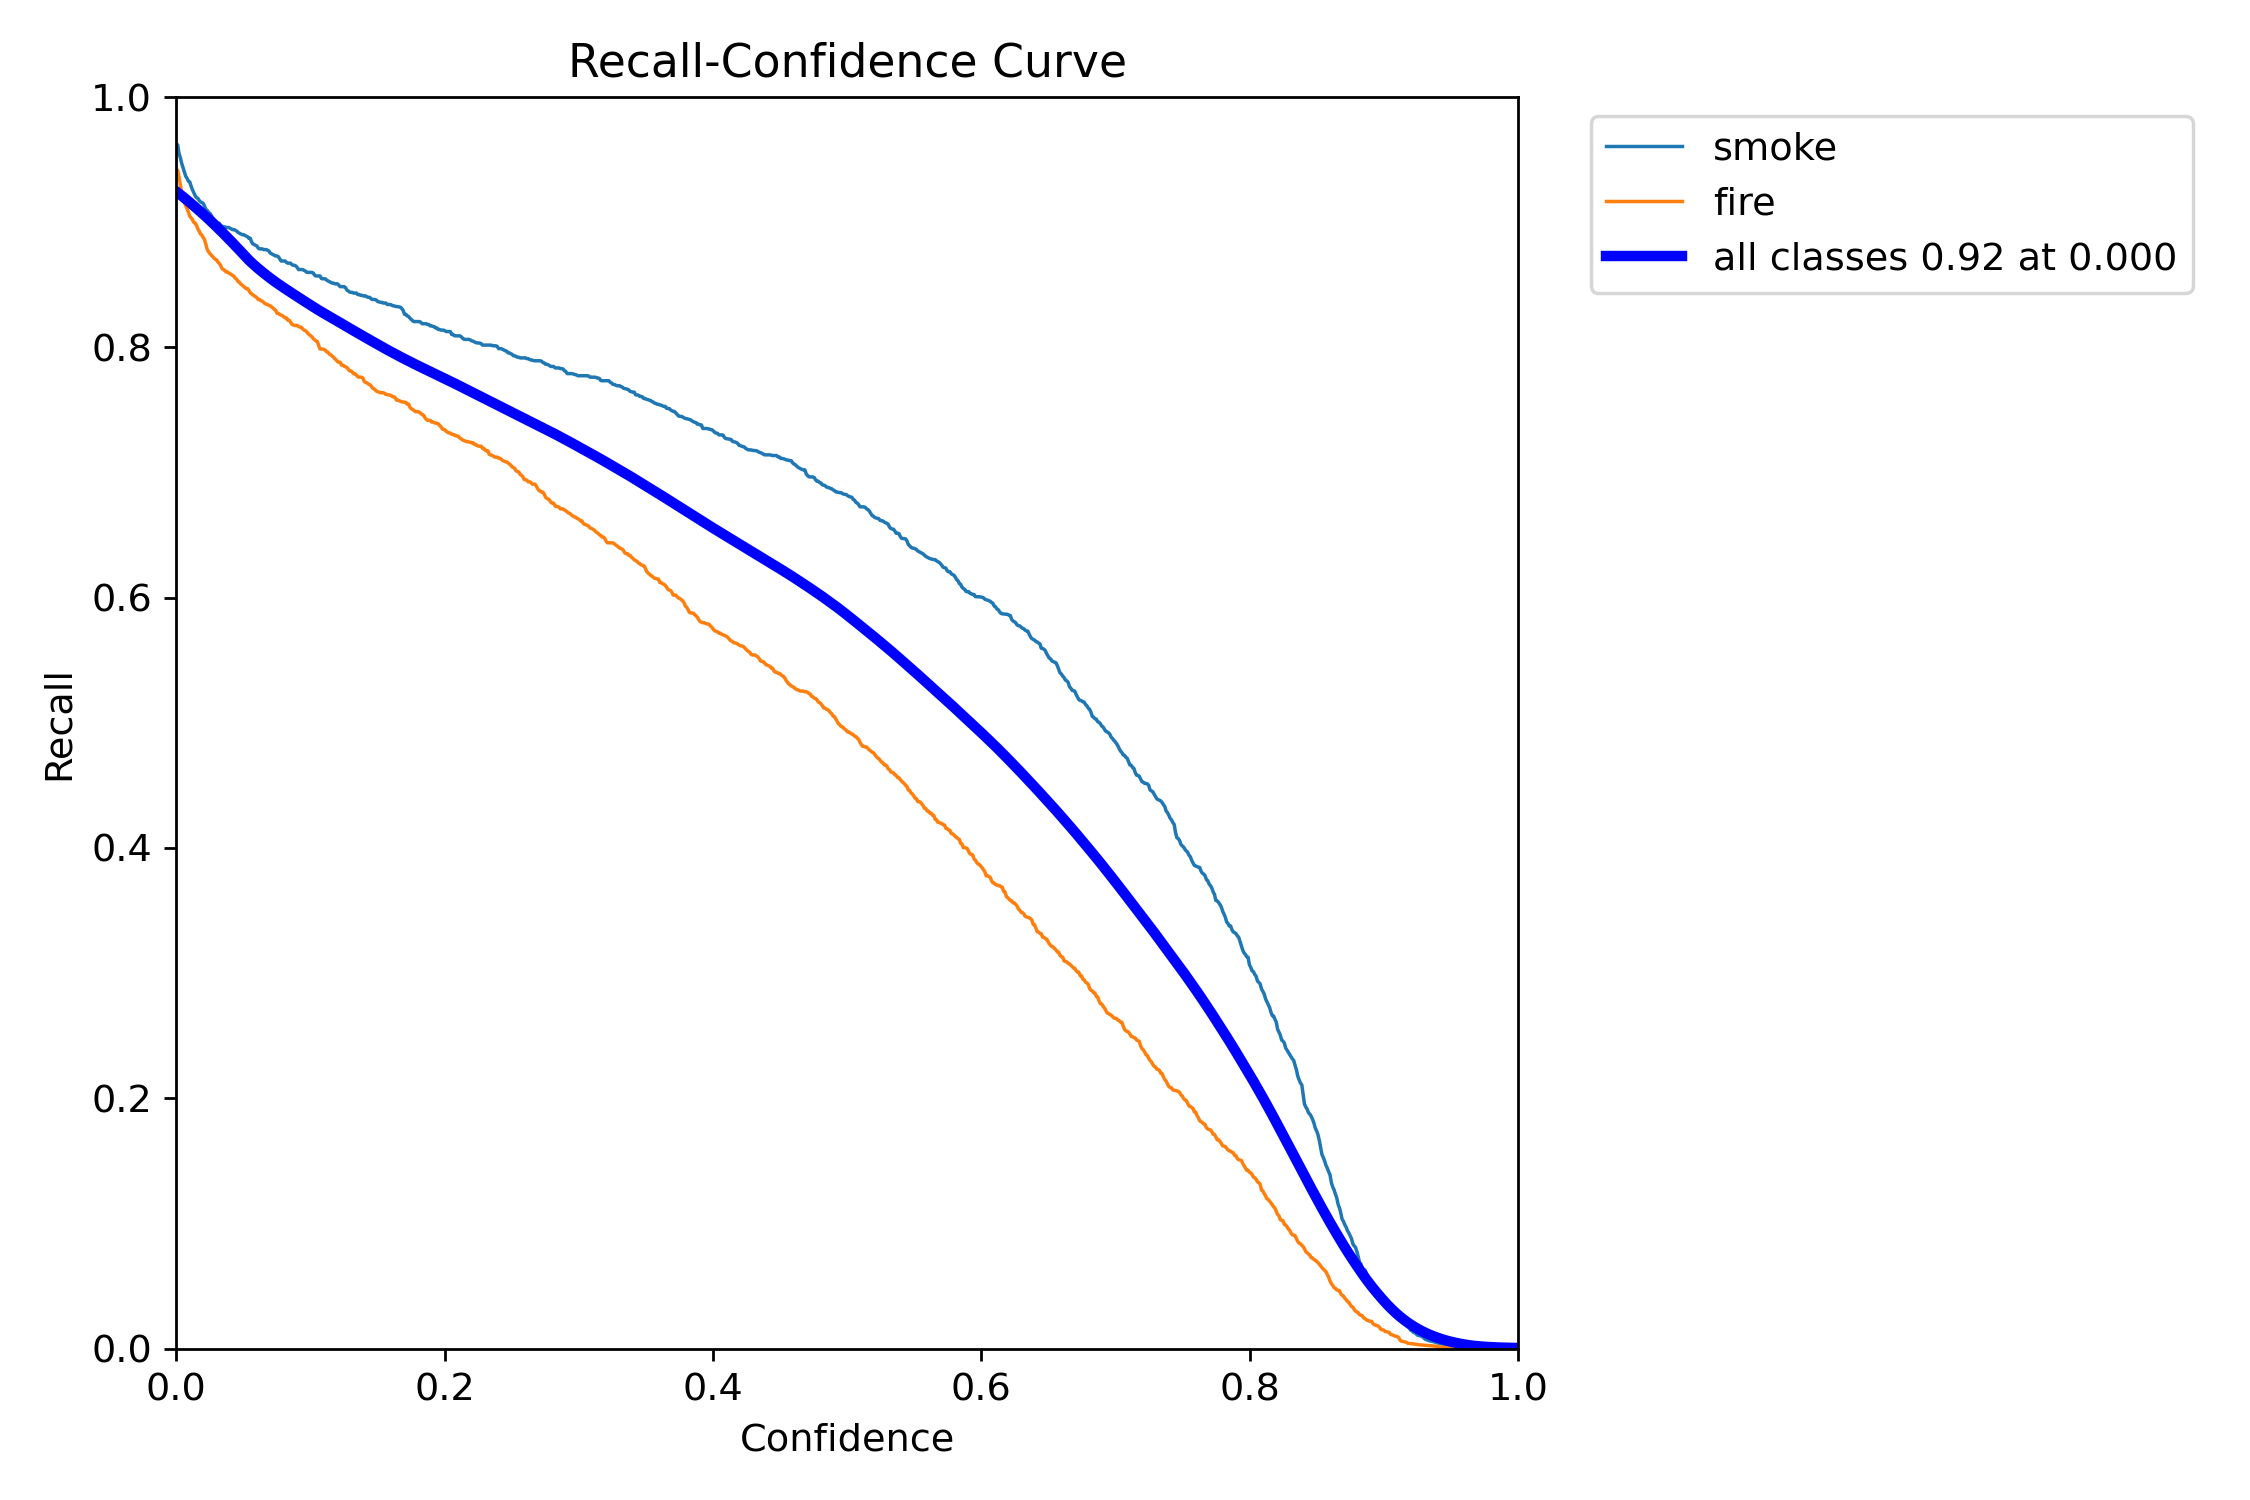


BoxF1_curve.png


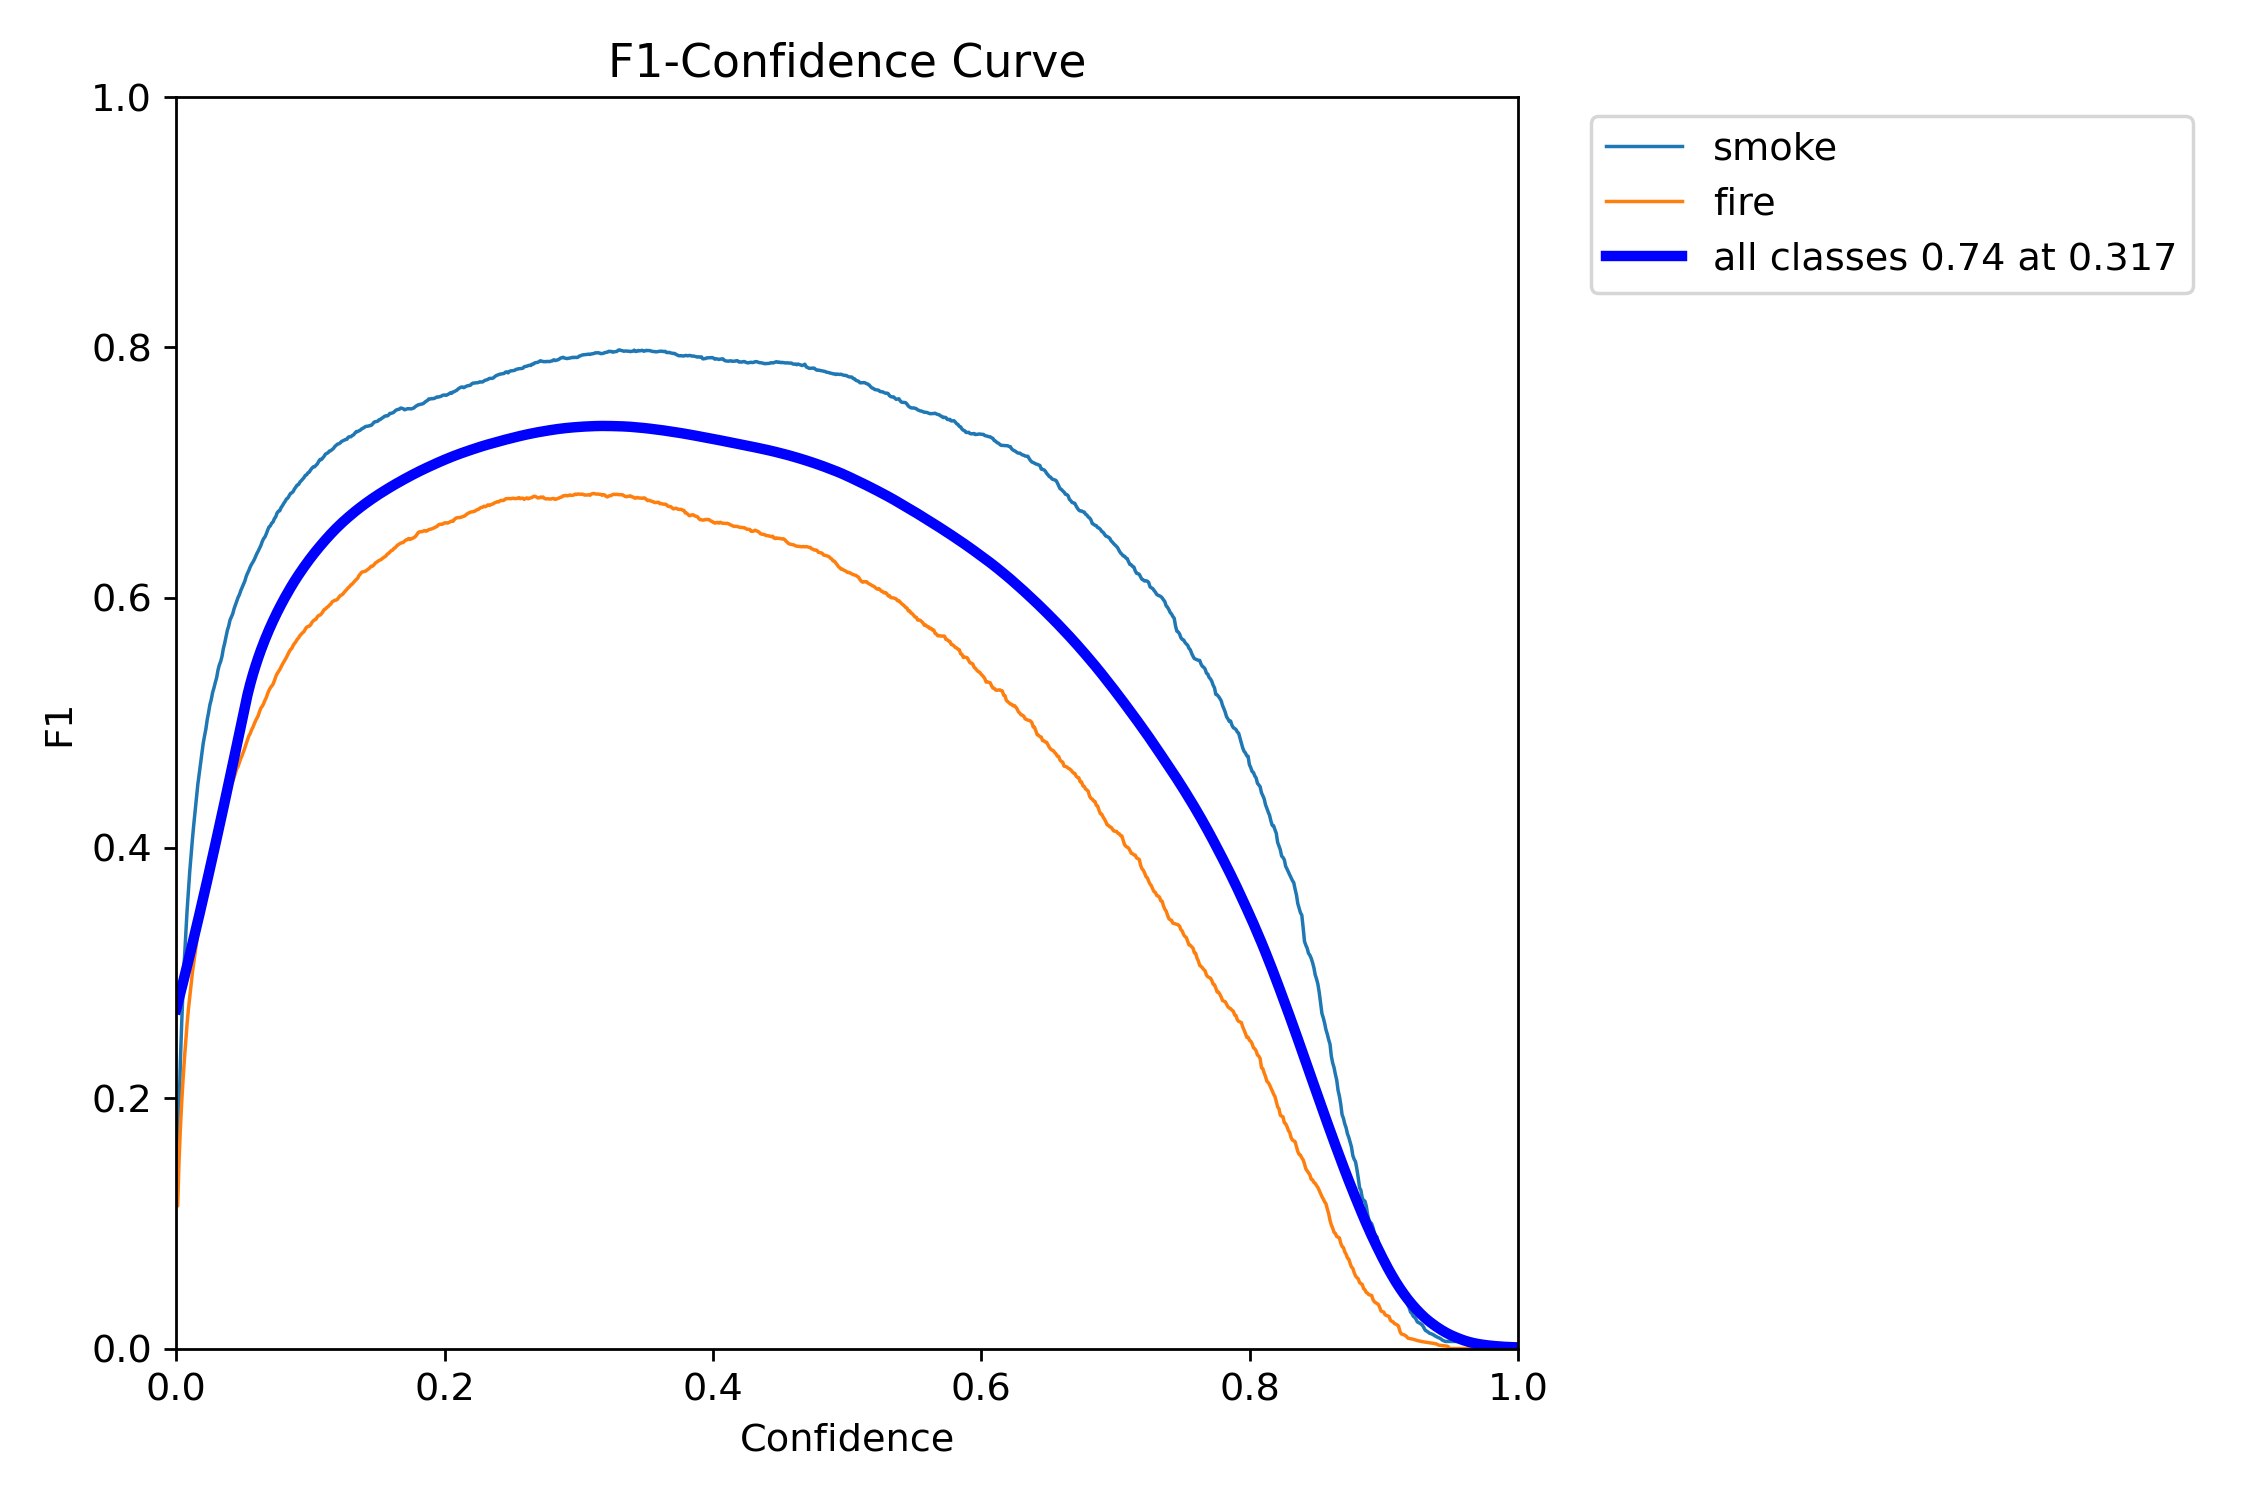

In [ ]:
from IPython.display import Image, display
import os

result_folder = "/content/runs/detect/FireSmokeDetection/YOLOv8s-3"

plots = [
    "results.png",
    "confusion_matrix.png",
    "confusion_matrix_normalized.png",
    "BoxPR_curve.png",
    "BoxP_curve.png",
    "BoxR_curve.png",
    "BoxF1_curve.png"
]

for plot in plots:
    path = os.path.join(result_folder, plot)

    print("\n" + "="*70)
    print(plot)
    print("="*70)

    display(Image(filename=path))

# 📷 Step 20: Test the Trained YOLOv8 Model on Test Images

Instead of uploading images manually, we will use images from the test dataset.

These are unseen images that were not used for training.

In [ ]:
import os
import random
from ultralytics import YOLO
from IPython.display import Image, display

# Load trained model
model = YOLO("/content/runs/detect/FireSmokeDetection/YOLOv8s-3/weights/best.pt")

# Test image folder
test_folder = "/content/fire_smoke_dataset/data/test/images"

# Select 5 random test images
sample_images = random.sample(os.listdir(test_folder), 5)

print("Selected Test Images:")
for img in sample_images:
    print("-", img)

Selected Test Images:
- WEB10565.jpg
- PublicDataset01066.jpg
- AoF06879.jpg
- AoF07182.jpg
- WEB10837.jpg


# 🔍 Step 21: Predict on Random Test Images

The trained model will predict objects on randomly selected test images.

The predictions (bounding boxes and confidence scores) will be displayed directly inside the notebook.

In [ ]:
from ultralytics import YOLO
from IPython.display import Image, display
import os
import random
import glob

# Load trained model
model = YOLO("/content/runs/detect/FireSmokeDetection/YOLOv8s-3/weights/best.pt")

# Folder containing test images
test_folder = "/content/fire_smoke_dataset/data/test/images"

# Select 5 random images
sample_images = random.sample(os.listdir(test_folder), 5)

for image_name in sample_images:

    image_path = os.path.join(test_folder, image_name)

    print("="*70)
    print("Testing:", image_name)
    print("="*70)

    # Run prediction
    model.predict(
        source=image_path,
        save=True,
        conf=0.25,
        imgsz=640,
        project="Predictions",
        name="TestImages",
        exist_ok=True,
        verbose=False
    )

# Find all predicted images
prediction_folder = "/content/Predictions/TestImages"

predicted_images = sorted(glob.glob(os.path.join(prediction_folder, "*.jpg")))

print(f"\n✅ Total predicted images: {len(predicted_images)}\n")

# Display them
for img in predicted_images[-5:]:   # show the latest 5 predictions
    display(Image(filename=img))

Testing: PublicDataset01122.jpg
Results saved to /content/runs/detect/Predictions/TestImages
Testing: WEB10827.jpg
Results saved to /content/runs/detect/Predictions/TestImages
Testing: AoF08057.jpg
Results saved to /content/runs/detect/Predictions/TestImages
Testing: PublicDataset01198.jpg
Results saved to /content/runs/detect/Predictions/TestImages
Testing: WEB09487.jpg
Results saved to /content/runs/detect/Predictions/TestImages

✅ Total predicted images: 0



In [ ]:
import os

prediction_folder = "/content/runs/detect/Predictions/TestImages"

print("Files inside prediction folder:\n")

for file in os.listdir(prediction_folder):
    print(file)

Files inside prediction folder:

AoF08057.jpg
WEB10827.jpg
WEB10565.jpg
PublicDataset01122.jpg
PublicDataset01198.jpg
WEB09487.jpg


# 🖼️ Step 22: Display Predicted Images

In this step, we display the predicted images generated by our trained YOLOv8 model.

Each image includes:
- 🔥 Fire detections
- 💨 Smoke detections
- 📦 Bounding boxes
- 📊 Confidence scores

✅ Total Predicted Images: 6

AoF08057.jpg


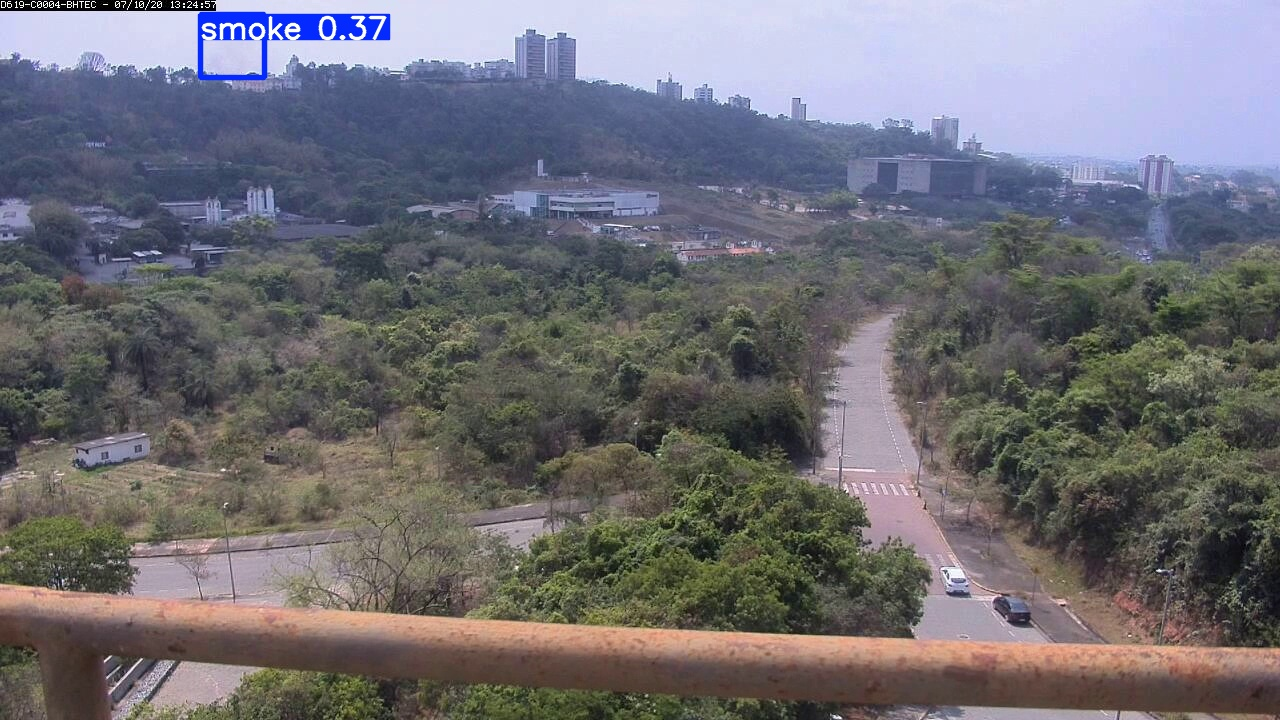

PublicDataset01122.jpg


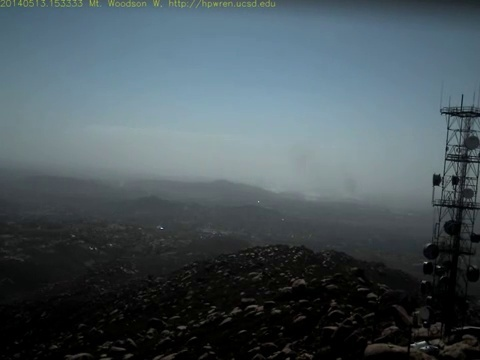

PublicDataset01198.jpg


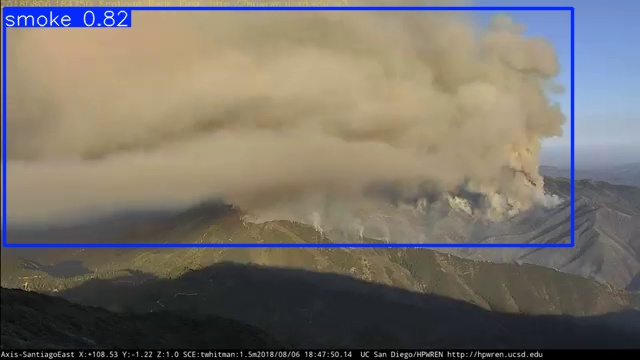

WEB09487.jpg


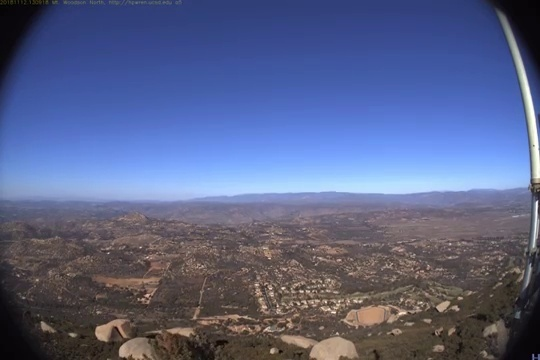

WEB10565.jpg


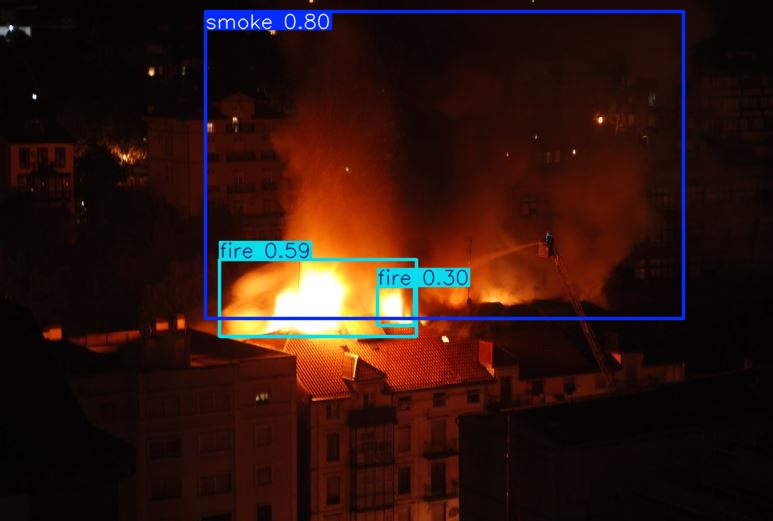

WEB10827.jpg


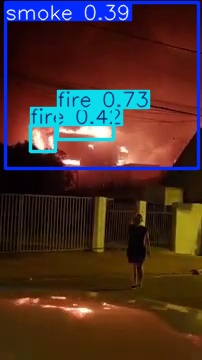

In [ ]:
from IPython.display import Image, display
import os

prediction_folder = "/content/runs/detect/Predictions/TestImages"

images = sorted(os.listdir(prediction_folder))

print(f"✅ Total Predicted Images: {len(images)}\n")

for img in images:
    print("=" * 70)
    print(img)
    print("=" * 70)

    display(Image(filename=os.path.join(prediction_folder, img)))

In [ ]:
import shutil

source = "/content/runs/detect/FireSmokeDetection/YOLOv8s-3/weights/best.pt"
destination = "/content/best_fire_smoke_detector.pt"

shutil.copy(source, destination)

print("Model saved successfully!")

Model saved successfully!


In [ ]:
from google.colab import files

files.download("/content/best_fire_smoke_detector.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Discussion

The YOLOv8s object detection model was successfully trained to detect both fire and smoke using a custom dataset. During training, the loss values consistently decreased while the precision, recall, and mAP values improved, indicating effective learning and stable convergence.

The trained model achieved good performance on the unseen test dataset with:

- Precision: **77.68%**
- Recall: **68.74%**
- mAP@50: **76.50%**
- mAP@50-95: **43.98%**

The confusion matrices and evaluation curves demonstrate that the model can correctly identify most fire and smoke instances. Prediction results on unseen test images further confirm that the trained model generalizes well to new data under various environmental conditions.

Overall, YOLOv8s provides a good balance between detection accuracy and inference speed, making it suitable for real-time fire and smoke detection applications.

# Conclusion

In this project, a YOLOv8s-based deep learning model was developed for automatic fire and smoke detection.

The model was trained on a labeled dataset containing two object classes: **fire** and **smoke**. After training for **40 epochs**, the model demonstrated strong detection capability on unseen test images while maintaining fast inference speed.

The evaluation metrics and qualitative prediction results indicate that the proposed system can accurately detect fire and smoke in various scenarios. Such a system can be integrated into intelligent surveillance systems, industrial safety monitoring, forest fire detection, and smart city applications for early fire warning.

Future improvements may include:
- Increasing dataset diversity
- Applying advanced data augmentation
- Training larger YOLO models (YOLOv8m or YOLOv8l)
- Optimizing hyperparameters
- Deploying the model on edge devices for real-time monitoring

# Overall Model Summary

| Item | Description |
|------|-------------|
| Model | YOLOv8s |
| Task | Fire and Smoke Detection |
| Framework | Ultralytics YOLOv8 |
| Deep Learning Library | PyTorch |
| Dataset Classes | Fire, Smoke |
| Number of Classes | 2 |
| Training Images | 14,122 |
| Validation Images | 3,099 |
| Testing Images | 4,306 |
| Training Epochs | 40 |
| Best Model | best_fire_smoke_detector.pt |
| Precision | 77.68% |
| Recall | 68.74% |
| mAP@50 | 76.50% |
| mAP@50-95 | 43.98% |
| Hardware | NVIDIA Tesla T4 GPU |
| Platform | Google Colab |